In [ ]:
from IPython.display import Image

In [ ]:
## Methods of Building LLM Powered Applications :

1. Prompt Engineering :
2. RAG :
3. AI Agents :
4. FineTuning :

## Prompt Engineering :

In [ ]:
Prompt : Input given to the LLM

Prompt Engineering : Designing prompt to get expected output

In [ ]:
# Context Engineering :
Context Engineering is designing, structuring & controlling all the information
we feed to LLM :

-- System Prompt
-- Retrieved Knowledges  (RAG)
-- Conversational Memory
-- Tool Context
-- Enforcing output structure

In [ ]:
Prompt Engineering : Writing better instructions
Context Engineering : Controlling all the input to model

In [ ]:
## Elements of Prompt :
-- Instruction : what you want exactly (write a code, write an email)
-- Context : Extra info about your task (Write an email to manger regarding sick levae)
-- Role : How to behave (Act as a python developer with 10 years of expericee)
-- Format : expected output format

In [ ]:
## Principles of Prompt Engineering :
1. Write clear and specific instructions
2. Give model time to think

In [ ]:
## Strategies to write better Prompt :

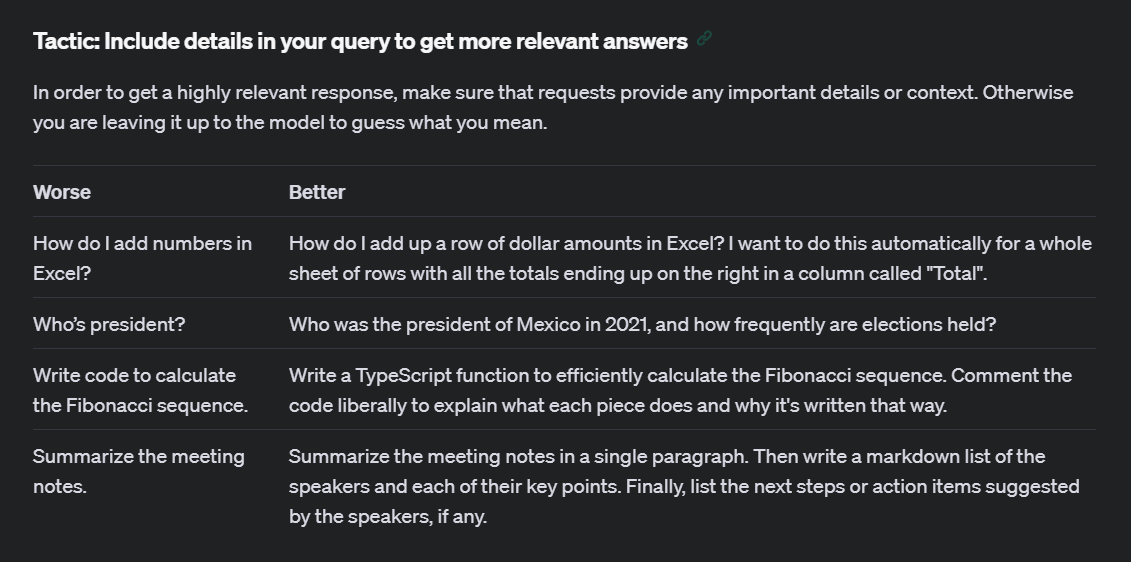

In [ ]:
## Include more details :

Image("/content/Prompt_include_imp_details.png")

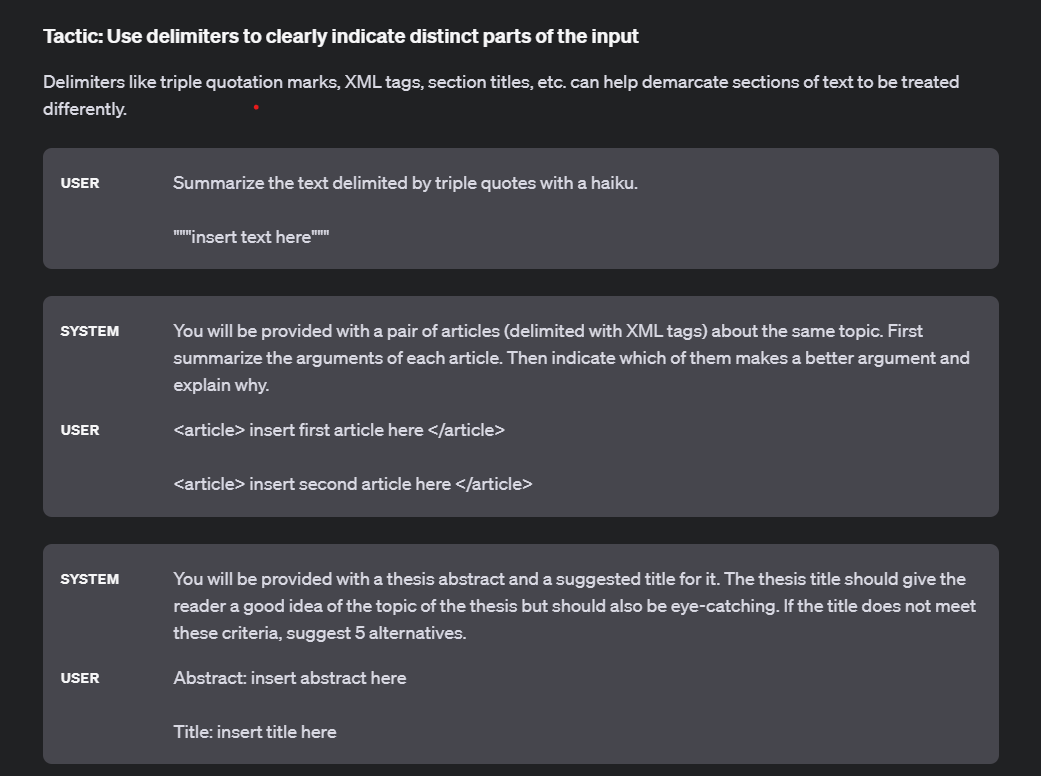

In [ ]:
## Seperate out Information :
Image("/content/Prompt_Use_delimeters.png")

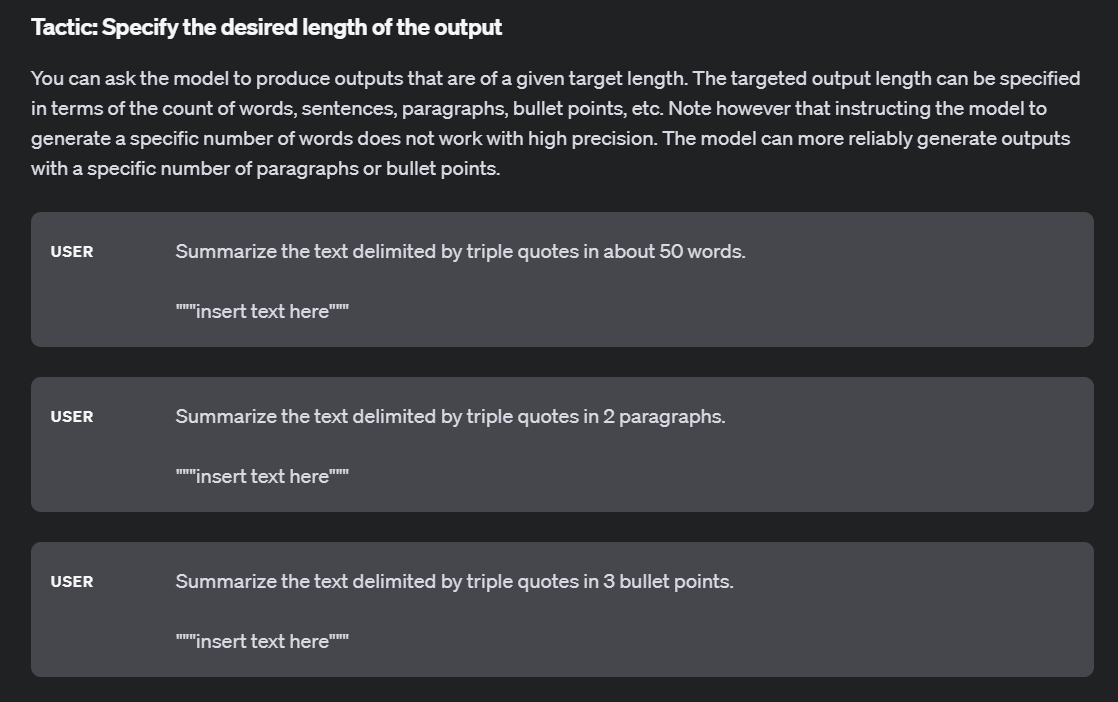

In [ ]:
## Specify length of output :
Image("/content/Prompt_specify_desired_length.png")

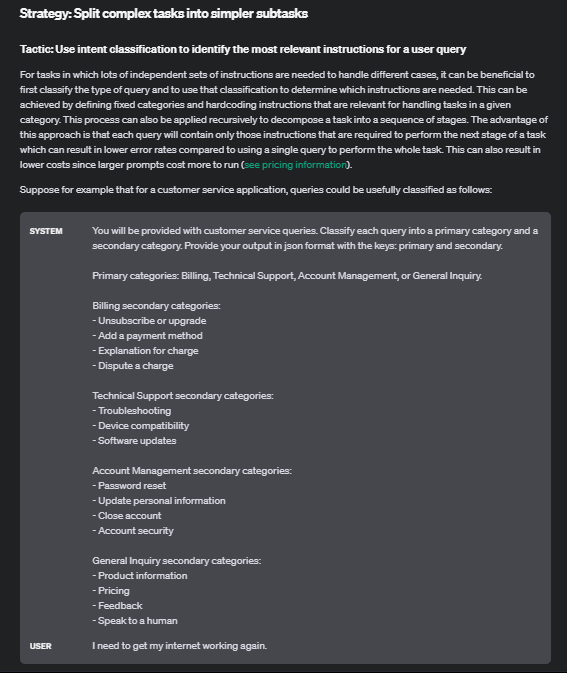

In [ ]:
## Split Complex task :
Image("/content/Prompt_split_complex_task_into_simpler.png")

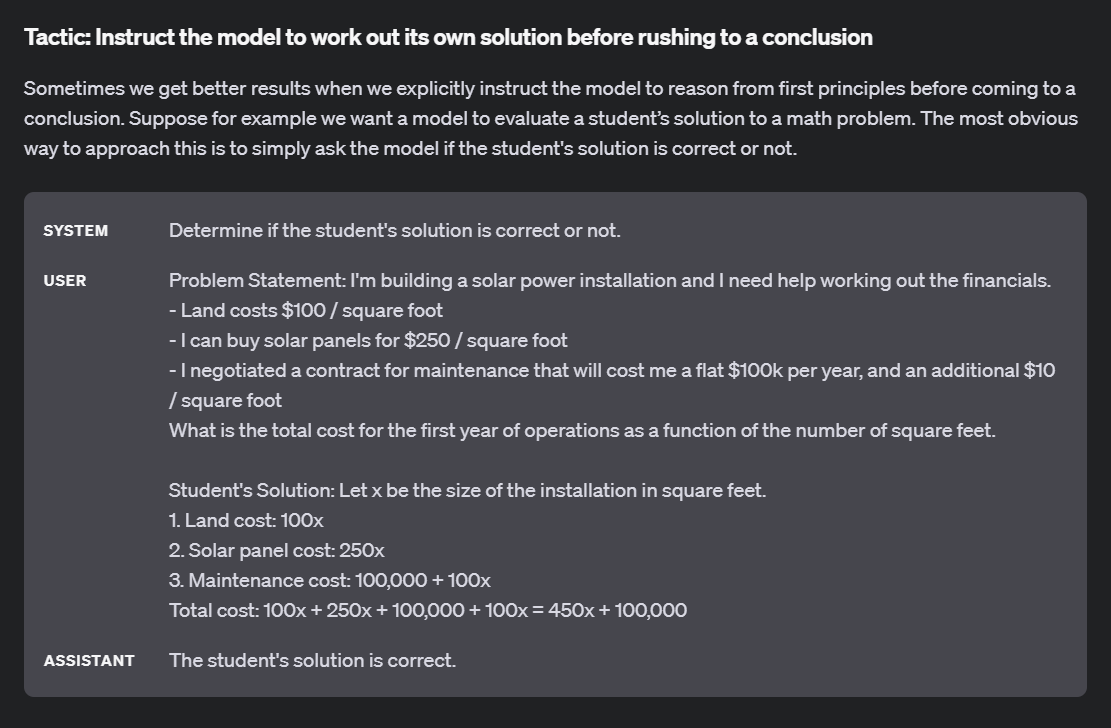

In [ ]:
## Solve the Problem :
Image("/content/Prompt_work_out_own_solution.png")

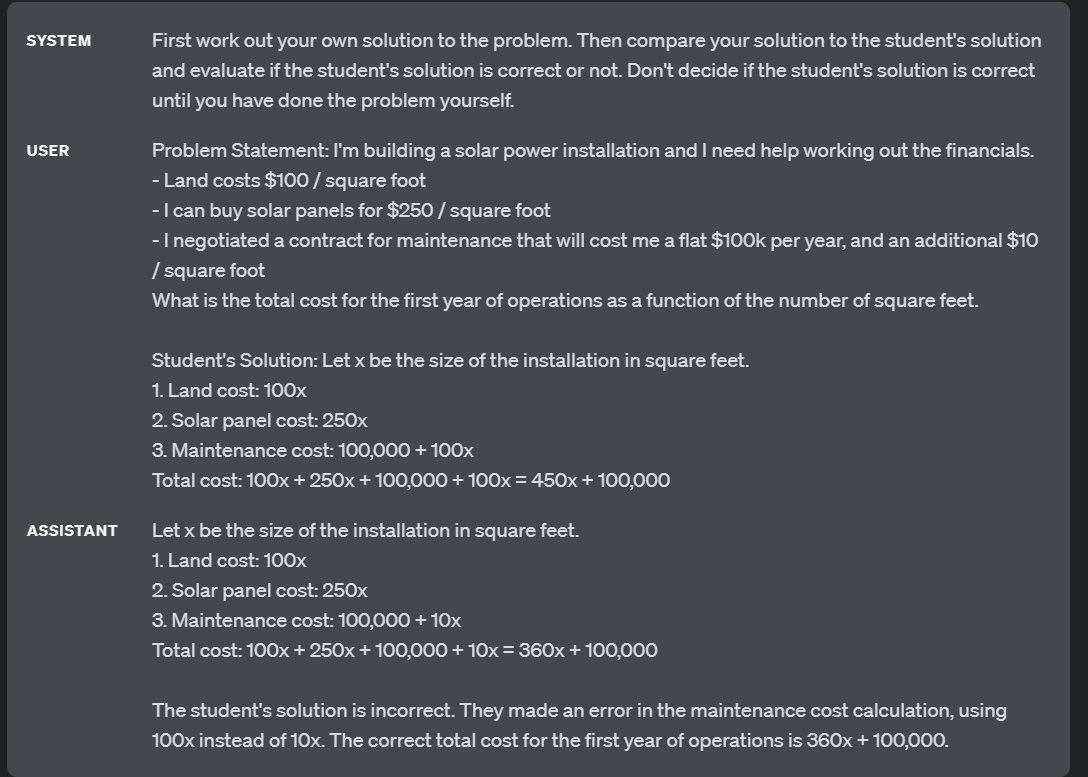

In [ ]:
Image("/content/Prompt_work_out_own_solution2.png")

## Prompting Techniques :

In [ ]:
from google.colab import userdata
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI')

In [ ]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.4 MB/s eta 0:00:00


In [ ]:
from langchain_openai import OpenAI

model = OpenAI()

####Shot Prompting :

In [ ]:
# Shot = Examples :
-- Zero shot :
-- One Shot :
-- Few Shot :

In [ ]:
## Zero Shot
model.invoke("Give me sentiment of given review, review : This product is bad")

'\n\nNegative sentiment'

In [ ]:
## One Shot
model.invoke("""model.invoke("Give me sentiment of given review,
review : this is good product, review : Positive
review : this is bad product, review :
""")

'Negative\n\n\nFor the review "this is good product", the sentiment is Positive.\n\nFor the review "this is bad product", the sentiment is Negative.'

In [ ]:
## Few Shot :
model.invoke("""model.invoke("Give me sentiment of given review, only return positive or negative
review : this is good product, review : Positive
review : this is bad product, review : Negative
review : this is best product, review : Positive
review : this is worst product, review : Negative
review : this is worst product, review :

""")

'Negative'

In [ ]:
## Limitations of Few-Shot Prompting :
-- Complex Task (Multi-step solution)

In [ ]:
model.invoke("""
The odd numbers in this group add up to an even number: 4, 8, 9, 15, 12, 2, 1.
A: The answer is False.

The odd numbers in this group add up to an even number: 17,  10, 19, 4, 8, 12, 24.
A: The answer is True.

The odd numbers in this group add up to an even number: 16,  11, 14, 4, 8, 13, 24.
A: The answer is True.

The odd numbers in this group add up to an even number: 17,  9, 10, 12, 13, 4, 2.
A: The answer is False.

The odd numbers in this group add up to an even number: 15, 32, 5, 13, 82, 7, 1.
A:
""")

'The answer is True.'

In [ ]:
#  15, 32, 5, 13, 82, 7, 1.
15 + 5 + 13 + 7 + 1

41

####Chain-of-Thought (CoT) :

In [ ]:
## Insted of providing direct answers, we also provide step on how to reach that anwert


In [ ]:
model.invoke("""
The odd numbers in this group add up to an even number: 4, 8, 9, 15, 12, 2, 1.
A: Adding all the odd numbers (9, 15, 1) gives 25. The answer is False.

The odd numbers in this group add up to an even number: 17,  10, 19, 4, 8, 12, 24.
A: Adding all the odd numbers (17, 19) gives 36. The answer is True.

The odd numbers in this group add up to an even number: 16,  11, 14, 4, 8, 13, 24.
A: Adding all the odd numbers (11, 13) gives 24. The answer is True.

The odd numbers in this group add up to an even number: 17,  9, 10, 12, 13, 4, 2.
A: Adding all the odd numbers (17, 9, 13) gives 39. The answer is False.

The odd numbers in this group add up to an even number: 15, 32, 5, 13, 82, 7, 1.
A:
""")

'Adding all the odd numbers (15, 5, 13, 7, 1) gives 41. The answer is False.'

In [ ]:
## Zero Shot CoT :
"Let's think step by step"

In [ ]:
model.invoke("""
The odd numbers in this group add up to an even number: 15, 32, 5, 13, 82, 7, 1.
True or False :

Let's think step by step
""")

'Step 1: Find the odd numbers in the group\nOdd numbers: 15, 5, 13, 7, 1\n\nStep 2: Add up the odd numbers\n15 + 5 + 13 + 7 + 1 = 41\n\nStep 3: Check if the sum is even or odd\nThe sum, 41, is an odd number.\n\nStep 4: Compare the sum to the original statement\nThe statement says that the odd numbers add up to an even number. This is not true because the sum of the odd numbers (41) is not an even number.\n\nTherefore, the statement is False.'

In [ ]:
Step 1: Find the odd numbers in the group
Odd numbers: 15, 5, 13, 7, 1

Step 2: Add up the odd numbers
15 + 5 + 13 + 7 + 1 = 41

Step 3: Check if the sum is even or odd
The sum, 41, is an odd number.

Step 4: Compare the sum to the original statement
The statement says that the odd numbers add up to an even number. This is not true because the sum of the odd numbers (41) is not an even number.

Therefore, the statement is False.

In [ ]:
model.invoke("""When I was 10 years old, my sister was half my age
now I am 60, how old is my sister?
""")

'\nYour sister is 55 years old.'

In [ ]:
model.invoke("""When I was 10 years old, my sister was half my age
now I am 60, how old is my sister?
""")

'\nYour sister is 55 years old.'

In [ ]:
30 year
55 year

####Self-Consistency :

In [ ]:
## Generte multiple answers & select final answer by majority voting

In [ ]:
model.invoke("""
Q: There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done,
there will be 21 trees. How many trees did the grove workers plant today?
A: We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted.
So, they must have planted 21 - 15 = 6 trees. The answer is 6.

Q: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
A: There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5.

Q: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
A: Leah had 32 chocolates and Leah’s sister had 42. That means there were originally 32 + 42 = 74
chocolates. 35 have been eaten. So in total they still have 74 - 35 = 39 chocolates. The answer is 39.

Q: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops
did Jason give to Denny?
A: Jason had 20 lollipops. Since he only has 12 now, he must have given the rest to Denny. The number of
lollipops he has given to Denny must have been 20 - 12 = 8 lollipops. The answer is 8.

Q: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does
he have now?
A: He has 5 toys. He got 2 from mom, so after that he has 5 + 2 = 7 toys. Then he got 2 more from dad, so
in total he has 7 + 2 = 9 toys. The answer is 9.

Q: There were nine computers in the server room. Five more computers were installed each day, from
monday to thursday. How many computers are now in the server room?
A: There are 4 days from monday to thursday. 5 computers were added each day. That means in total 4 * 5 =
20 computers were added. There were 9 computers in the beginning, so now there are 9 + 20 = 29 computers.
The answer is 29.

Q: Michael had 58 golf balls. On tuesday, he lost 23 golf balls. On wednesday, he lost 2 more. How many
golf balls did he have at the end of wednesday?
A: Michael initially had 58 balls. He lost 23 on Tuesday, so after that he has 58 - 23 = 35 balls. On
Wednesday he lost 2 more so now he has 35 - 2 = 33 balls. The answer is 33.

Q: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
A: She bought 5 bagels for $3 each. This means she spent $15. She has $8 left.

Q: When I was 6 my sister was half my age. Now I’m 70 how old is my sister?
A:
""")

'\nWhen you were 6, your sister was half your age, so she must have been 6/2 = 3 years old. Now, you are 70\nand she is 3 years younger, so she must be 70 - 3 = 67 years old. The answer is 67.'

####Tree-of-Thought :

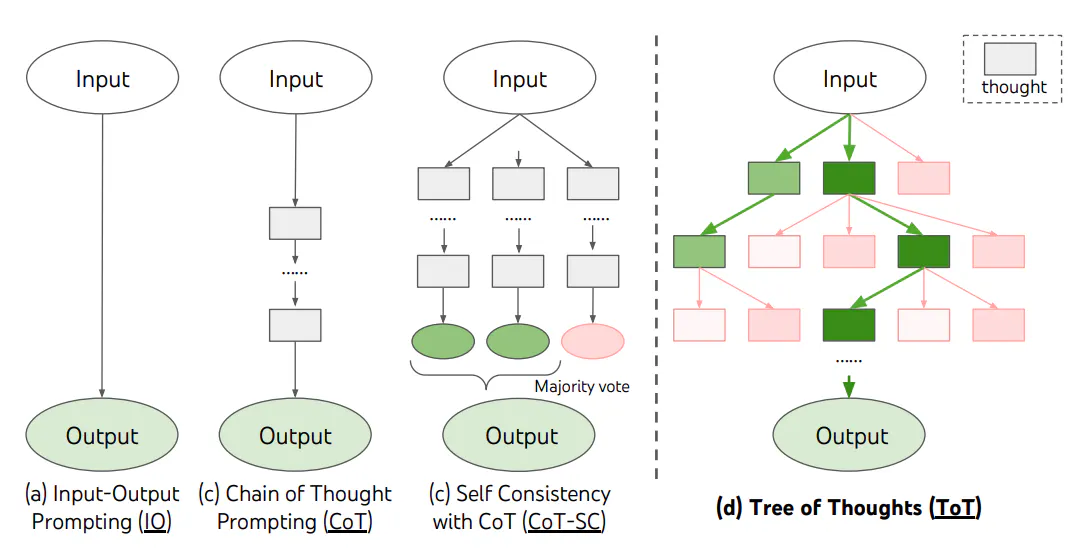

In [ ]:
from IPython.display import Image
Image("/content/ToT.jpg", width=500)

In [ ]:
output = model.invoke("""
Imagine three different experts are answering this question.
All experts will write down 1 step of their thinking,
then share it with the group.
Then all experts will go on to the next step, etc.
If any expert realises they're wrong at any point then they leave.
all expert will decide one final answer. and return that final answer.
The question is : how many vehicles are there in bengaluru?
give me approx number
""",
max_tokens=-1)

In [ ]:
print(output)


Expert 1:
Step 1: Gather data on the population of Bengaluru and the average household size.
Step 2: Estimate the percentage of households that own at least one vehicle.
Step 3: Multiply the number of households by the percentage to get an estimate of the total number of vehicles in Bengaluru.

Expert 2:
Step 1: Conduct a survey or study to determine the number of registered vehicles in Bengaluru.
Step 2: Take into account the number of unregistered vehicles, such as those used for public transportation.
Step 3: Adjust for any seasonal or temporary fluctuations in vehicle ownership.

Expert 3:
Step 1: Analyze traffic patterns and volume in Bengaluru to estimate the number of vehicles on the roads.
Step 2: Consider the percentage of vehicles that may be parked or not in use at any given time.
Step 3: Take into account any recent changes in population or transportation trends in Bengaluru.

Final answer: After considering all three experts' approaches and discussions, we estimate the nu